In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [2]:
import json
import re
from pathlib import Path
from statistics import mean
from itertools import combinations
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr, kendalltau

pair_rows = []
run_rows = []

# set your parent folder here
base_folder = Path(".")

# the 4 directories you want to parse
target_dirs = [
    "attack_discount_framing",
    "attack_scarcity",
    "exclusivity",
    "social_proof",
]


def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def get_attack_id(filename):
    """
    Extract numeric id from filenames like:
    ..._0.json
    ..._0_defence.json
    """
    m = re.search(r"_(\d+)(?:_defence)?\.json$", filename)
    return int(m.group(1)) if m else None


def find_all_ranking_lists(obj):
    """
    Recursively collect all lists of dicts shaped like:
    {'llm_output': ..., 'se_output': ...}
    """
    results = []

    if isinstance(obj, list):
        if obj and all(isinstance(x, dict) for x in obj):
            if all("llm_output" in x and "se_output" in x for x in obj):
                results.append(obj)

        for item in obj:
            results.extend(find_all_ranking_lists(item))

    elif isinstance(obj, dict):
        for value in obj.values():
            results.extend(find_all_ranking_lists(value))

    return results


def ranking_to_product_rank_map(ranking):
    """
    Convert:
    [{'llm_output': 0, 'se_output': 9}, ...]
    into:
    {9: 0, ...}
    """
    return {row["se_output"]: row["llm_output"] for row in ranking}


def kendall_tau_distance_from_rank_lists(ranks_a, ranks_b):
    """
    Normalized Kendall tau distance:
    0 = identical
    1 = complete reversal
    """
    n = len(ranks_a)
    if n < 2:
        return 0.0

    discordant = 0
    total = 0

    for i, j in combinations(range(n), 2):
        a = ranks_a[i] - ranks_a[j]
        b = ranks_b[i] - ranks_b[j]
        if a * b < 0:
            discordant += 1
        total += 1

    return discordant / total if total else 0.0


def compute_ranking_metrics(non_def_ranking, def_ranking):
    """
    Match products by se_output, compare llm_output ranks.
    """
    non_def_map = ranking_to_product_rank_map(non_def_ranking)
    def_map = ranking_to_product_rank_map(def_ranking)

    common_products = sorted(set(non_def_map) & set(def_map))
    if not common_products:
        raise ValueError("No common products found between the two rankings.")

    ranks_non_def = [non_def_map[p] for p in common_products]
    ranks_def = [def_map[p] for p in common_products]

    abs_diffs = [abs(a - b) for a, b in zip(ranks_non_def, ranks_def)]
    sq_diffs = [(a - b) ** 2 for a, b in zip(ranks_non_def, ranks_def)]

    spearman_corr, _ = spearmanr(ranks_non_def, ranks_def)
    kendall_corr, _ = kendalltau(ranks_non_def, ranks_def)
    kendall_dist = kendall_tau_distance_from_rank_lists(ranks_non_def, ranks_def)

    return {
        "avg_abs_displacement": sum(abs_diffs) / len(abs_diffs),
        "sum_abs_displacement": sum(abs_diffs),
        "sum_squared_displacement": sum(sq_diffs),
        "spearman_corr": float(spearman_corr),
        "kendall_tau_corr": float(kendall_corr),
        "kendall_tau_distance": float(kendall_dist),
    }


def mean_metric(run_metrics, key):
    values = [m[key] for m in run_metrics]
    return mean(values)


def collect_file_pairs(folder):
    """
    Collect defence / non-defence files by numeric attack id.
    """
    defense_files = {}
    non_defense_files = {}

    for path in folder.glob("*.json"):
        attack_id = get_attack_id(path.name)
        if attack_id is None:
            continue

        if "defence" in path.name.lower():
            defense_files[attack_id] = path
        else:
            non_defense_files[attack_id] = path

    return defense_files, non_defense_files


all_run_metrics_global = []

for dir_name in target_dirs:
    folder = base_folder / dir_name

    if not folder.exists():
        print(f"\nSkipping missing directory: {dir_name}")
        continue

    print(f"\n{'=' * 80}")
    print(f"DIRECTORY: {dir_name}")
    print(f"{'=' * 80}")

    defense_files, non_defense_files = collect_file_pairs(folder)
    pair_results = {}

    for attack_id in sorted(non_defense_files):
        if attack_id not in defense_files:
            print(f"Skipping attack {attack_id} in {dir_name}: missing defence file")
            continue

        non_def_path = non_defense_files[attack_id]
        def_path = defense_files[attack_id]

        non_def_data = load_json(non_def_path)
        def_data = load_json(def_path)

        non_def_runs = find_all_ranking_lists(non_def_data)
        def_runs = find_all_ranking_lists(def_data)

        n_runs = min(len(non_def_runs), len(def_runs))
        if n_runs == 0:
            print(f"Skipping attack {attack_id} in {dir_name}: no ranking runs found")
            continue

        run_metrics = []

        for run_idx in range(n_runs):
            metrics = compute_ranking_metrics(
                non_def_runs[run_idx],
                def_runs[run_idx]
            )
            run_metrics.append(metrics)
            all_run_metrics_global.append(metrics)

            run_rows.append({
                "directory": dir_name,
                "attack_id": attack_id,
                "run_id": run_idx,
                "sum_squared_displacement": metrics["sum_squared_displacement"],
                "avg_abs_displacement": metrics["avg_abs_displacement"],
                "sum_abs_displacement": metrics["sum_abs_displacement"],
                "spearman_corr": metrics["spearman_corr"],
                "kendall_tau_corr": metrics["kendall_tau_corr"],
                "kendall_tau_distance": metrics["kendall_tau_distance"],
            })

        pair_results[attack_id] = {
            "non_defense_file": non_def_path.name,
            "defense_file": def_path.name,
            "num_runs_used": n_runs,
            "run_metrics": run_metrics,
            "mean_avg_abs_displacement": mean_metric(run_metrics, "avg_abs_displacement"),
            "mean_sum_abs_displacement": mean_metric(run_metrics, "sum_abs_displacement"),
            "mean_sum_squared_displacement": mean_metric(run_metrics, "sum_squared_displacement"),
            "mean_spearman_corr": mean_metric(run_metrics, "spearman_corr"),
            "mean_kendall_tau_corr": mean_metric(run_metrics, "kendall_tau_corr"),
            "mean_kendall_tau_distance": mean_metric(run_metrics, "kendall_tau_distance"),
        }
        pair_rows.append({
            "directory": dir_name,
            "attack_id": attack_id,
            "non_defense_file": non_def_path.name,
            "defense_file": def_path.name,
            "num_runs_used": n_runs,
            "mean_sum_squared_displacement": mean_metric(run_metrics, "sum_squared_displacement"),
            "std_sum_squared_displacement": pd.Series([m["sum_squared_displacement"] for m in run_metrics]).std(ddof=1),
            "mean_avg_abs_displacement": mean_metric(run_metrics, "avg_abs_displacement"),
            "std_avg_abs_displacement": pd.Series([m["avg_abs_displacement"] for m in run_metrics]).std(ddof=1),
            "mean_spearman_corr": mean_metric(run_metrics, "spearman_corr"),
            "std_spearman_corr": pd.Series([m["spearman_corr"] for m in run_metrics]).std(ddof=1),
            "mean_kendall_tau_corr": mean_metric(run_metrics, "kendall_tau_corr"),
            "std_kendall_tau_corr": pd.Series([m["kendall_tau_corr"] for m in run_metrics]).std(ddof=1),
            "mean_kendall_tau_distance": mean_metric(run_metrics, "kendall_tau_distance"),
            "std_kendall_tau_distance": pd.Series([m["kendall_tau_distance"] for m in run_metrics]).std(ddof=1),
        })

    # print per-pair results
    print("\nPer-file-pair results")
    for attack_id, result in pair_results.items():
        print(f"\nAttack {attack_id}")
        print(f"  Non-defence: {result['non_defense_file']}")
        print(f"  Defence:     {result['defense_file']}")
        print(f"  Runs used:   {result['num_runs_used']}")
        print(f"  Mean avg|Δ|:               {result['mean_avg_abs_displacement']:.4f}")
        print(f"  Mean sum|Δ|:               {result['mean_sum_abs_displacement']:.4f}")
        print(f"  Mean sum(Δ²):              {result['mean_sum_squared_displacement']:.4f}")
        print(f"  Mean Spearman correlation: {result['mean_spearman_corr']:.4f}")
        print(f"  Mean Kendall tau:          {result['mean_kendall_tau_corr']:.4f}")
        print(f"  Mean Kendall distance:     {result['mean_kendall_tau_distance']:.4f}")

    # directory-level averages
    dir_run_metrics = []
    for result in pair_results.values():
        dir_run_metrics.extend(result["run_metrics"])

    if dir_run_metrics:
        print(f"\nDirectory-level means for {dir_name}")
        print(f"  avg|Δ|:               {mean_metric(dir_run_metrics, 'avg_abs_displacement'):.4f}")
        print(f"  sum|Δ|:               {mean_metric(dir_run_metrics, 'sum_abs_displacement'):.4f}")
        print(f"  sum(Δ²):              {mean_metric(dir_run_metrics, 'sum_squared_displacement'):.4f}")
        print(f"  Spearman correlation: {mean_metric(dir_run_metrics, 'spearman_corr'):.4f}")
        print(f"  Kendall tau:          {mean_metric(dir_run_metrics, 'kendall_tau_corr'):.4f}")
        print(f"  Kendall distance:     {mean_metric(dir_run_metrics, 'kendall_tau_distance'):.4f}")
    else:
        print(f"\nNo valid run metrics found in {dir_name}.")


# overall means across all directories
if all_run_metrics_global:
    print(f"\n{'=' * 80}")
    print("OVERALL MEANS ACROSS ALL DIRECTORIES")
    print(f"{'=' * 80}")
    print(f"  avg|Δ|:               {mean_metric(all_run_metrics_global, 'avg_abs_displacement'):.4f}")
    print(f"  sum|Δ|:               {mean_metric(all_run_metrics_global, 'sum_abs_displacement'):.4f}")
    print(f"  sum(Δ²):              {mean_metric(all_run_metrics_global, 'sum_squared_displacement'):.4f}")
    print(f"  Spearman correlation: {mean_metric(all_run_metrics_global, 'spearman_corr'):.4f}")
    print(f"  Kendall tau:          {mean_metric(all_run_metrics_global, 'kendall_tau_corr'):.4f}")
    print(f"  Kendall distance:     {mean_metric(all_run_metrics_global, 'kendall_tau_distance'):.4f}")
else:
    print("\nNo valid run metrics found overall.")

run_df = pd.DataFrame(run_rows)
pair_df = pd.DataFrame(pair_rows)

print("run_df shape:", run_df.shape)
print("pair_df shape:", pair_df.shape)
display(run_df.head())
display(pair_df.head())


DIRECTORY: attack_discount_framing

Per-file-pair results

Attack 0
  Non-defence: experiment_binoculars_abstract_Qwen___Qwen3-0.6B_attack_discount_framing_0.json
  Defence:     experiment_binoculars_abstract_Qwen___Qwen3-0.6B_attack_discount_framing_0_defence.json
  Runs used:   20
  Mean avg|Δ|:               2.9548
  Mean sum|Δ|:               19.9000
  Mean sum(Δ²):              86.0000
  Mean Spearman correlation: -0.1644
  Mean Kendall tau:          -0.1111
  Mean Kendall distance:     0.5556

Attack 1
  Non-defence: experiment_binoculars_abstract_Qwen___Qwen3-0.6B_attack_discount_framing_1.json
  Defence:     experiment_binoculars_abstract_Qwen___Qwen3-0.6B_attack_discount_framing_1_defence.json
  Runs used:   20
  Mean avg|Δ|:               2.6426
  Mean sum|Δ|:               15.4000
  Mean sum(Δ²):              63.0000
  Mean Spearman correlation: -0.0393
  Mean Kendall tau:          -0.0410
  Mean Kendall distance:     0.5205

Attack 2
  Non-defence: experiment_binoculars_ab

,directory,attack_id,run_id,sum_squared_displacement,avg_abs_displacement,sum_abs_displacement,spearman_corr,kendall_tau_corr,kendall_tau_distance
0,attack_discount_framing,0,0,66,2.571429,18,0.357143,0.238095,0.380952
1,attack_discount_framing,0,1,122,3.714286,26,-0.857143,-0.714286,0.857143
2,attack_discount_framing,0,2,106,2.888889,26,0.116667,0.111111,0.444444
3,attack_discount_framing,0,3,31,1.857143,13,0.607143,0.428571,0.285714
4,attack_discount_framing,0,4,83,3.166667,19,-0.485714,-0.333333,0.666667


,directory,attack_id,non_defense_file,defense_file,num_runs_used,mean_sum_squared_displacement,std_sum_squared_displacement,mean_avg_abs_displacement,std_avg_abs_displacement,mean_spearman_corr,std_spearman_corr,mean_kendall_tau_corr,std_kendall_tau_corr,mean_kendall_tau_distance,std_kendall_tau_distance
0,attack_discount_framing,0,experiment_binoculars_abstract_Qwen___Qwen3-0....,experiment_binoculars_abstract_Qwen___Qwen3-0....,20,86.00,32.916161,2.954802,0.609947,-0.164405,0.410079,-0.111111,0.290761,0.555556,0.145380
1,attack_discount_framing,1,experiment_binoculars_abstract_Qwen___Qwen3-0....,experiment_binoculars_abstract_Qwen___Qwen3-0....,20,63.00,32.505870,2.642619,0.948943,-0.039286,0.491061,-0.040952,0.390984,0.520476,0.195492
2,attack_discount_framing,2,experiment_binoculars_abstract_Qwen___Qwen3-0....,experiment_binoculars_abstract_Qwen___Qwen3-0....,20,52.70,31.117942,2.295794,0.744356,0.222143,0.480483,0.150635,0.374728,0.424683,0.187364
3,attack_discount_framing,3,experiment_binoculars_abstract_Qwen___Qwen3-0....,experiment_binoculars_abstract_Qwen___Qwen3-0....,20,72.95,44.800699,2.689663,0.829789,-0.168452,0.510969,-0.122143,0.446907,0.561071,0.223453
4,attack_discount_framing,4,experiment_binoculars_abstract_Qwen___Qwen3-0....,experiment_binoculars_abstract_Qwen___Qwen3-0....,20,67.10,27.220155,2.706925,0.621407,-0.086667,0.425070,-0.053492,0.356597,0.526746,0.178299


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

plt.rcParams.update({
    "figure.figsize": (9, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

In [4]:
family_order = [
    "attack_discount_framing",
    "attack_scarcity",
    "exclusivity",
    "social_proof",
]

family_labels = {
    "attack_discount_framing": "Discount framing",
    "attack_scarcity": "Scarcity",
    "exclusivity": "Exclusivity",
    "social_proof": "Social proof",
}

family_palette = dict(zip(
    family_order,
    sns.color_palette("Set2", n_colors=len(family_order))
))

In [5]:
plot_cols = [
    "directory",
    "attack_id",
    "run_id",
    "sum_squared_displacement",
    "sum_abs_displacement",
    "avg_abs_displacement",
    "spearman_corr",
    "kendall_tau_corr",
    "kendall_tau_distance",
]

plot_df = run_df[plot_cols].copy()

for col in plot_cols:
    if col not in ["directory", "attack_id", "run_id"]:
        plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce")

plot_df = plot_df.dropna(subset=["directory"])
plot_df["directory"] = pd.Categorical(
    plot_df["directory"],
    categories=family_order,
    ordered=True
)

plot_df["directory_label"] = plot_df["directory"].map(family_labels)

plot_df.head()

,directory,attack_id,run_id,sum_squared_displacement,sum_abs_displacement,avg_abs_displacement,spearman_corr,kendall_tau_corr,kendall_tau_distance,directory_label
0,attack_discount_framing,0,0,66,18,2.571429,0.357143,0.238095,0.380952,Discount framing
1,attack_discount_framing,0,1,122,26,3.714286,-0.857143,-0.714286,0.857143,Discount framing
2,attack_discount_framing,0,2,106,26,2.888889,0.116667,0.111111,0.444444,Discount framing
3,attack_discount_framing,0,3,31,13,1.857143,0.607143,0.428571,0.285714,Discount framing
4,attack_discount_framing,0,4,83,19,3.166667,-0.485714,-0.333333,0.666667,Discount framing


In [6]:
def metric_summary(df, metric, group_col="directory"):
    out = (
        df.groupby(group_col)[metric]
        .agg(
            n="count",
            mean="mean",
            std="std",
            median="median",
            q1=lambda x: x.quantile(0.25),
            q3=lambda x: x.quantile(0.75),
            min="min",
            max="max",
        )
        .reset_index()
    )
    out["iqr"] = out["q3"] - out["q1"]
    return out.sort_values("mean", ascending=False)

In [7]:
def add_summary_markers(ax, df, x_col, y_col, order):
    summary = (
        df.groupby(x_col)[y_col]
        .agg(mean="mean", median="median", std="std")
        .reindex(order)
        .reset_index()
    )

    xs = np.arange(len(summary))

    ax.scatter(
        xs,
        summary["mean"],
        marker="D",
        s=80,
        color="crimson",
        label="Mean",
        zorder=6,
    )

    ax.scatter(
        xs,
        summary["median"],
        marker="o",
        s=55,
        color="navy",
        label="Median",
        zorder=6,
    )

    return summary

In [8]:
def plot_displacement_metric(
    df,
    metric,
    title,
    ylabel,
    order=None,
    palette=None,
    sample_points=2500,
    show_points=True,
    kind="boxen",
):
    data = df[["directory", "directory_label", metric]].dropna().copy()

    if order is None:
        order = (
            data.groupby("directory")[metric]
            .median()
            .sort_values(ascending=False)
            .index.tolist()
        )

    fig, ax = plt.subplots(figsize=(9, 5))

    if kind == "violin":
        sns.violinplot(
            data=data,
            x="directory",
            y=metric,
            order=order,
            palette=palette,
            inner=None,
            cut=0,
            linewidth=1.2,
            ax=ax,
        )
        sns.boxplot(
            data=data,
            x="directory",
            y=metric,
            order=order,
            width=0.18,
            showcaps=True,
            boxprops={"facecolor": "white", "zorder": 5},
            showfliers=False,
            whiskerprops={"linewidth": 1.2},
            medianprops={"color": "black", "linewidth": 2},
            ax=ax,
        )
    else:
        sns.boxenplot(
            data=data,
            x="directory",
            y=metric,
            order=order,
            palette=palette,
            linewidth=1.2,
            k_depth="proportion",
            ax=ax,
        )

    if show_points:
        if len(data) > sample_points:
            points_df = data.sample(sample_points, random_state=42)
        else:
            points_df = data

        sns.stripplot(
            data=points_df,
            x="directory",
            y=metric,
            order=order,
            color="black",
            alpha=0.28,
            size=4,
            jitter=0.18,
            ax=ax,
        )

    summary = add_summary_markers(ax, data, "directory", metric, order)

    label_order = [
        family_labels.get(cat, str(cat))
        for cat in order
    ]

    x = np.arange(len(summary))

    ax.set_xticks(x)
    ax.set_xticklabels(label_order, rotation=18, ha="right")

    ax.set_title(title, pad=12)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()

    return summary

In [9]:
def plot_bounded_metric_distribution(
    df,
    metric,
    title,
    ylabel,
    order=None,
    palette=None,
    ylim=None,
):
    data = df[["directory", metric]].dropna().copy()

    if order is None:
        order = (
            data.groupby("directory")[metric]
            .median()
            .sort_values(ascending=False)
            .index.tolist()
        )

    fig, ax = plt.subplots(figsize=(9, 5))

    sns.boxplot(
        data=data,
        x="directory",
        y=metric,
        order=order,
        palette=palette,
        width=0.55,
        fliersize=0,
        linewidth=1.4,
        ax=ax,
    )

    summary = add_summary_markers(ax, data, "directory", metric, order)

    x = np.arange(len(summary))

    ax.set_xticks(x)
    ax.set_xticklabels(
        [family_labels.get(cat, str(cat)) for cat in order],
        rotation=18,
        ha="right"
    )
    ax.set_title(title, pad=12)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)

    if ylim is not None:
        ax.set_ylim(*ylim)

    plt.tight_layout()
    plt.show()

    return summary

In [10]:
def plot_bounded_metric_summary(
    df,
    metric,
    title,
    ylabel,
    order=None,
    ylim=None,
    figsize=(8.5, 4.8),
):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    plt.close("all")

    data = df[["directory", metric]].copy()
    data["directory"] = data["directory"].astype(str)
    data[metric] = pd.to_numeric(data[metric], errors="coerce")
    data = data.dropna(subset=["directory", metric])

    if order is None:
        order = (
            data.groupby("directory", observed=True)[metric]
            .mean()
            .sort_values(ascending=False)
            .index.tolist()
        )

    summary = (
        data.groupby("directory", observed=True)[metric]
        .agg(["mean", "std", "median", "count"])
        .reindex(order)
        .reset_index()
        .rename(columns={"count": "n"})
    )

    # Replace NaN std values, which happen when n=1
    summary["std"] = summary["std"].fillna(0)

    x = np.arange(len(summary))

    fig, ax = plt.subplots(figsize=figsize)

    ax.errorbar(
        x,
        summary["mean"].to_numpy(),
        yerr=summary["std"].to_numpy(),
        fmt="o",
        capsize=5,
        markersize=7,
        linewidth=1.8,
    )

    ax.scatter(
        x,
        summary["median"].to_numpy(),
        marker="_",
        s=280,
        color="black",
        zorder=5,
        label="Median",
    )
    x = np.arange(len(summary))
    
    ax.set_xticks(x)
    ax.set_xticklabels(
        [family_labels.get(cat, str(cat)) for cat in summary["directory"]],
        rotation=18,
        ha="right"
    )

    ax.set_title(title, fontsize=13, pad=8)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)

    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()

    return summary

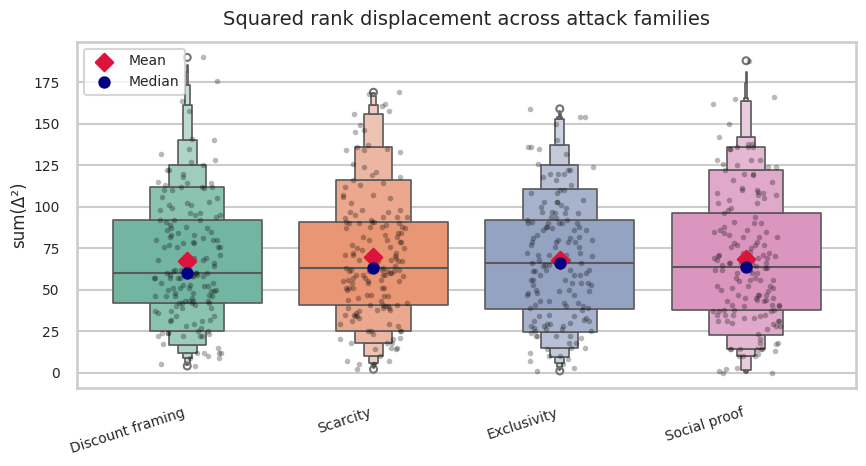

In [11]:
summary_sum_delta2 = plot_displacement_metric(
    plot_df,
    metric="sum_squared_displacement",
    title="Squared rank displacement across attack families",
    ylabel="sum(Δ²)",
    order=family_order,
    palette=family_palette,
    kind="boxen",
)

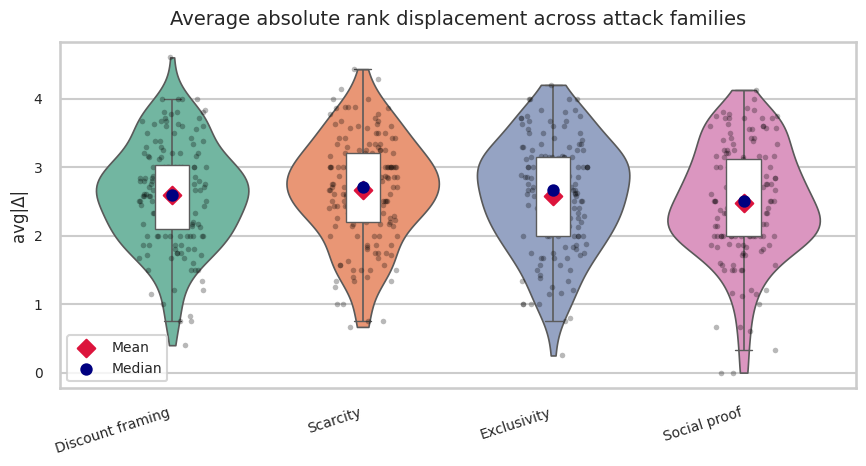

In [12]:
summary_avg_abs = plot_displacement_metric(
    plot_df,
    metric="avg_abs_displacement",
    title="Average absolute rank displacement across attack families",
    ylabel="avg|Δ|",
    order=family_order,
    palette=family_palette,
    kind="violin",
)

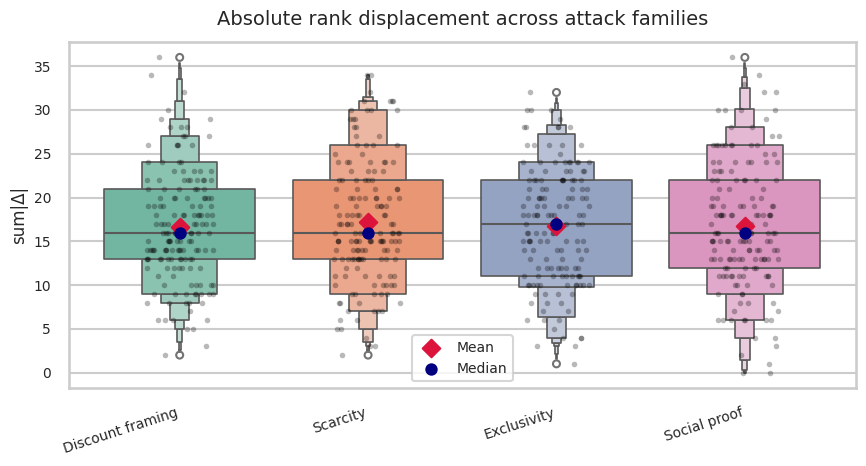

In [13]:
summary_sum_abs = plot_displacement_metric(
    plot_df,
    metric="sum_abs_displacement",
    title="Absolute rank displacement across attack families",
    ylabel="sum|Δ|",
    order=family_order,
    palette=family_palette,
    kind="boxen",
)

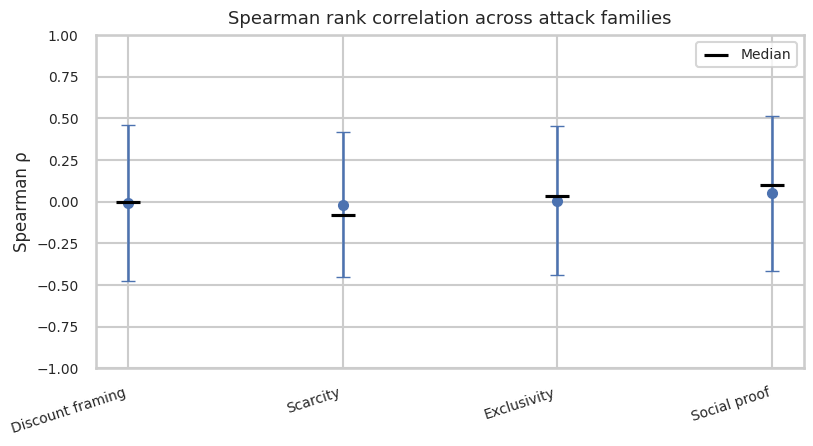

In [14]:
summary_spearman = plot_bounded_metric_summary(
    plot_df,
    metric="spearman_corr",
    title="Spearman rank correlation across attack families",
    ylabel="Spearman ρ",
    order=family_order,
    #palette_name="Blues",
    ylim=(-1, 1),
)

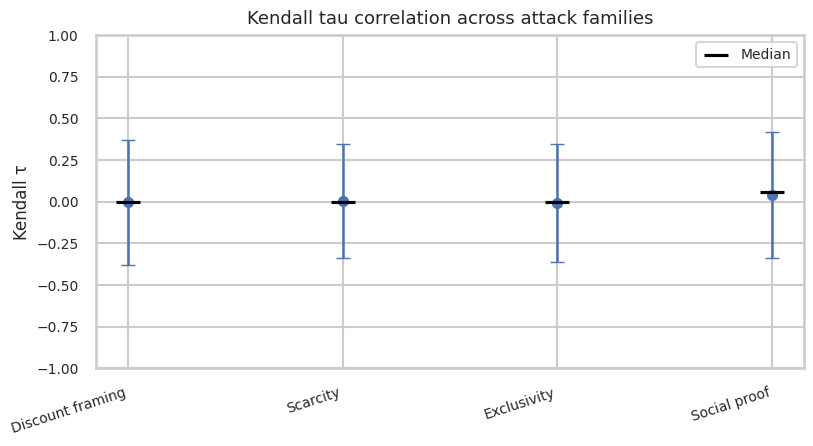

In [15]:
summary_kendall = plot_bounded_metric_summary(
    plot_df,
    metric="kendall_tau_corr",
    title="Kendall tau correlation across attack families",
    ylabel="Kendall τ",
    order=family_order,
    #palette_name="Greens",
    ylim=(-1, 1),
)

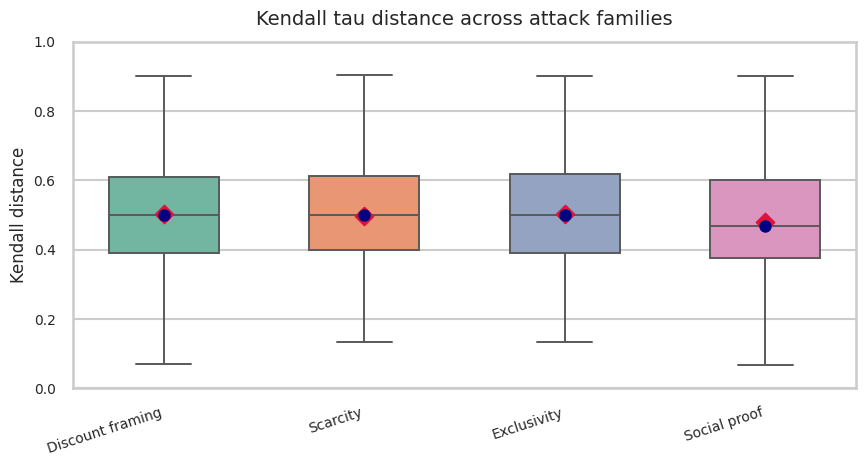

In [16]:
summary_kdist = plot_bounded_metric_distribution(
    plot_df,
    metric="kendall_tau_distance",
    title="Kendall tau distance across attack families",
    ylabel="Kendall distance",
    order=family_order,
    palette=family_palette,
    ylim=(0, 1),
)

In [17]:
def make_report_table(df):
    metrics = [
        "sum_squared_displacement",
        "sum_abs_displacement",
        "avg_abs_displacement",
        "spearman_corr",
        "kendall_tau_corr",
        "kendall_tau_distance",
    ]

    pieces = []
    for metric in metrics:
        tmp = metric_summary(df, metric)
        tmp["metric"] = metric
        pieces.append(tmp)

    report = pd.concat(pieces, ignore_index=True)
    return report[[
        "metric", "directory", "n", "mean", "std", "median", "q1", "q3", "iqr", "min", "max"
    ]]

report_table = make_report_table(plot_df)
report_table

,metric,directory,n,mean,std,median,q1,q3,iqr,min,max
0,sum_squared_displacement,attack_scarcity,160,69.512500,38.171574,63.000000,41.000000,91.000000,50.000000,2.000000,169.000000
1,sum_squared_displacement,social_proof,160,68.337500,40.476235,63.500000,37.750000,96.500000,58.750000,0.000000,188.000000
2,sum_squared_displacement,exclusivity,151,67.642384,36.881313,66.000000,38.500000,92.000000,53.500000,1.000000,159.000000
3,sum_squared_displacement,attack_discount_framing,160,67.506250,36.566816,60.000000,42.000000,92.000000,50.000000,4.000000,190.000000
4,sum_abs_displacement,attack_scarcity,160,17.150000,6.955564,16.000000,13.000000,22.000000,9.000000,2.000000,34.000000
5,sum_abs_displacement,social_proof,160,16.787500,7.254916,16.000000,12.000000,22.000000,10.000000,0.000000,36.000000
6,sum_abs_displacement,exclusivity,151,16.768212,6.667777,17.000000,11.000000,22.000000,11.000000,1.000000,32.000000
7,sum_abs_displacement,attack_discount_framing,160,16.618750,6.307500,16.000000,13.000000,21.000000,8.000000,2.000000,36.000000
8,avg_abs_displacement,attack_scarcity,160,2.659201,0.767520,2.714286,2.191667,3.200000,1.008333,0.666667,4.428571
9,avg_abs_displacement,attack_discount_framing,160,2.587641,0.757970,2.585714,2.093750,3.027778,0.934028,0.400000,4.600000
